In [1]:
# Notebook 06 — Joint Training Experiment (Reviewer's Simplified Architecture)
#
# Goal: test whether the reviewer's simplified architecture
#       x → ConceptBlock → DecisionBlock, trained jointly with auxiliary
#       concept supervision, beats PRISM-F1's staged training (val AUC 0.7402).

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import roc_auc_score

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths
PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
CHECKPOINTS_DIR = PROJECT_ROOT / 'checkpoints'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'

X_TRAIN_PICKLE = DATA_DIR / 'x_train.pkl'
KAGGLE_TRAIN_CSV = DATA_DIR / 'train.csv'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

INPUT_DIM = 13
CONCEPT_DIM = 6

FEATURE_NAMES = [
    'lap_time_norm', 'lap_time_delta', 'cumulative_degradation',
    'tyre_life_norm', 'compound_soft', 'compound_medium', 'compound_hard',
    'compound_inter', 'compound_wet', 'position_norm', 'position_change_norm',
    'race_progress', 'stint_norm',
]
CONCEPT_NAMES = [
    'degradation_severity', 'pace_decay_rate', 'strategic_window',
    'track_position_risk', 'undercut_pressure', 'endgame_proximity',
]

In [3]:
# ── Define the joint model
class JointConceptBlock(nn.Module):
    """The reviewer's proposed simplified architecture.
    Reads x directly (no Reader, no latent z) and produces 6 concept scores.
    Slightly larger hidden dim (32) than PRISM's ConceptBlock (16) since
    it's processing raw x instead of refined z.
    """
    def __init__(self, input_dim=INPUT_DIM, concept_dim=CONCEPT_DIM, hidden_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, concept_dim)
    
    def forward(self, x):
        h = F.relu(self.ln1(self.fc1(x)))
        c = torch.sigmoid(self.fc2(h))
        return c


class JointDecisionBlock(nn.Module):
    """Linear head: concepts → pit logit. Same as PRISM's DecisionBlock."""
    def __init__(self, concept_dim=CONCEPT_DIM):
        super().__init__()
        self.linear = nn.Linear(concept_dim, 1)
    
    def forward(self, c):
        logit = self.linear(c).squeeze(-1)
        return logit


class JointModel(nn.Module):
    """End-to-end joint model: x → ConceptBlock → DecisionBlock → logit."""
    def __init__(self):
        super().__init__()
        self.concept_block = JointConceptBlock()
        self.decision_block = JointDecisionBlock()
    
    def forward(self, x):
        c = self.concept_block(x)
        logit = self.decision_block(c)
        return logit, c

In [4]:
# ── Load data and build split
print("=" * 70)
print("LOADING DATA AND BUILDING SPLIT")
print("=" * 70)

x_train_df = pd.read_pickle(X_TRAIN_PICKLE)
x_cols = [f'x_{n}' for n in FEATURE_NAMES]
c_cols = [f'c_{n}' for n in CONCEPT_NAMES]

x_arr = x_train_df[x_cols].values.astype(np.float32)
c_gt_arr = x_train_df[c_cols].values.astype(np.float32)
pit_arr = x_train_df['PitNextLap'].values.astype(np.int64)

# Race-year split (same logic as Stage 3 for fair comparison)
kaggle_train_raw = pd.read_csv(KAGGLE_TRAIN_CSV)
kaggle_train_raw.columns = kaggle_train_raw.columns.str.strip()
race_year = kaggle_train_raw['Race'].astype(str) + '_' + kaggle_train_raw['Year'].astype(str)
unique_combos = race_year.unique()

rng = np.random.RandomState(SEED)
shuffled = rng.permutation(len(unique_combos))
n_val = int(0.2 * len(unique_combos))
val_combos = set(unique_combos[shuffled[:n_val]])
train_mask = ~race_year.isin(val_combos).values
val_mask = race_year.isin(val_combos).values

x_train_t = torch.from_numpy(x_arr[train_mask])
c_train_t = torch.from_numpy(c_gt_arr[train_mask])
pit_train_t = torch.from_numpy(pit_arr[train_mask]).float()
x_val_t = torch.from_numpy(x_arr[val_mask])
c_val_t = torch.from_numpy(c_gt_arr[val_mask])
pit_val_t = torch.from_numpy(pit_arr[val_mask]).float()

BATCH_SIZE = 256
train_loader = DataLoader(
    TensorDataset(x_train_t, c_train_t, pit_train_t),
    batch_size=BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)
val_loader = DataLoader(
    TensorDataset(x_val_t, c_val_t, pit_val_t),
    batch_size=BATCH_SIZE, shuffle=False,
)

print(f"  Train: {train_mask.sum():,} rows  Val: {val_mask.sum():,} rows")
print(f"  Train pit rate: {pit_arr[train_mask].mean()*100:.2f}%")
print(f"  Val pit rate:   {pit_arr[val_mask].mean()*100:.2f}%")

pos_weight = (pit_arr[train_mask] == 0).sum() / max((pit_arr[train_mask] == 1).sum(), 1)
pos_weight_t = torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
print(f"  pos_weight (for BCE): {pos_weight:.3f}")


LOADING DATA AND BUILDING SPLIT
  Train: 359,899 rows  Val: 79,241 rows
  Train pit rate: 19.28%
  Val pit rate:   22.69%
  pos_weight (for BCE): 4.186


In [11]:
# ── Training
print("\n" + "=" * 70)
print("TRAINING JOINT MODEL")
print("=" * 70)

torch.manual_seed(SEED)
model = JointModel().to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"\n  Total parameters: {n_params:,}")
print(f"    ConceptBlock:   {sum(p.numel() for p in model.concept_block.parameters()):,}")
print(f"    DecisionBlock:  {sum(p.numel() for p in model.decision_block.parameters())}")
print(f"  (For comparison, PRISM-F1 runtime: 3,357 params)")

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
LAMBDA_CONCEPT = 0.5

EPOCHS = 50
PATIENCE = 10
best_val_auc = 0.0
best_epoch = 0
epochs_since_improvement = 0
best_state = None
history = {
    'epoch': [], 'train_loss_total': [], 'train_loss_pit': [], 'train_loss_concept': [],
    'val_loss_total': [], 'val_auc': [], 'val_concept_mse': [],
}

print(f"\n{'epoch':>5s} | {'tr_loss':>8s} | {'tr_pit':>7s} | {'tr_cpt':>7s} | "
      f"{'val_loss':>9s} | {'val_auc':>7s} | {'val_cpt':>7s} | {'time':>5s} | note")
print("-" * 100)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    
    # Train
    model.train()
    sum_total, sum_pit, sum_concept = 0.0, 0.0, 0.0
    n = 0
    for xb, cb, pb in train_loader:
        xb = xb.to(DEVICE); cb = cb.to(DEVICE); pb = pb.to(DEVICE)
        optimizer.zero_grad()
        logit, c_pred = model(xb)
        loss_pit = F.binary_cross_entropy_with_logits(logit, pb, pos_weight=pos_weight_t)
        loss_concept = F.mse_loss(c_pred, cb)
        loss = loss_pit + LAMBDA_CONCEPT * loss_concept
        loss.backward()
        optimizer.step()
        sum_total += loss.item() * xb.size(0)
        sum_pit += loss_pit.item() * xb.size(0)
        sum_concept += loss_concept.item() * xb.size(0)
        n += xb.size(0)
    
    train_loss_total = sum_total / n
    train_loss_pit = sum_pit / n
    train_loss_concept = sum_concept / n
    
    # Val
    model.eval()
    sum_total, sum_concept = 0.0, 0.0
    n = 0
    all_logits, all_probs, all_targets = [], [], []
    with torch.no_grad():
        for xb, cb, pb in val_loader:
            xb = xb.to(DEVICE); cb = cb.to(DEVICE); pb = pb.to(DEVICE)
            logit, c_pred = model(xb)
            loss_pit = F.binary_cross_entropy_with_logits(logit, pb, pos_weight=pos_weight_t)
            loss_concept = F.mse_loss(c_pred, cb)
            loss = loss_pit + LAMBDA_CONCEPT * loss_concept
            sum_total += loss.item() * xb.size(0)
            sum_concept += loss_concept.item() * xb.size(0)
            n += xb.size(0)
            all_logits.append(logit.cpu().numpy())
            all_probs.append(torch.sigmoid(logit).cpu().numpy())
            all_targets.append(pb.cpu().numpy())
    val_loss_total = sum_total / n
    val_concept_mse = sum_concept / n
    val_probs = np.concatenate(all_probs)
    val_targets = np.concatenate(all_targets)
    val_auc = roc_auc_score(val_targets, val_probs)
    
    history['epoch'].append(epoch)
    history['train_loss_total'].append(train_loss_total)
    history['train_loss_pit'].append(train_loss_pit)
    history['train_loss_concept'].append(train_loss_concept)
    history['val_loss_total'].append(val_loss_total)
    history['val_auc'].append(val_auc)
    history['val_concept_mse'].append(val_concept_mse)
    
    note = ""
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch
        epochs_since_improvement = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        note = "↑ new best"
    else:
        epochs_since_improvement += 1
        if epochs_since_improvement >= PATIENCE:
            note = "early stop"
    
    elapsed = time.time() - t0
    print(f"{epoch:>5d} | {train_loss_total:>8.4f} | {train_loss_pit:>7.4f} | {train_loss_concept:>7.4f} | "
          f"{val_loss_total:>9.4f} | {val_auc:>7.4f} | {val_concept_mse:>7.4f} | {elapsed:>5.1f} | {note}")
    
    if epochs_since_improvement >= PATIENCE:
        break



TRAINING JOINT MODEL

  Total parameters: 717
    ConceptBlock:   710
    DecisionBlock:  7
  (For comparison, PRISM-F1 runtime: 3,357 params)

epoch |  tr_loss |  tr_pit |  tr_cpt |  val_loss | val_auc | val_cpt |  time | note
----------------------------------------------------------------------------------------------------
    1 |   0.8862 |  0.8239 |  0.1247 |    0.8370 |  0.8680 |  0.1048 |  10.4 | ↑ new best
    2 |   0.6995 |  0.6483 |  0.1025 |    0.7852 |  0.8803 |  0.0898 |   8.7 | ↑ new best
    3 |   0.6638 |  0.6207 |  0.0862 |    0.7594 |  0.8866 |  0.0733 |   8.5 | ↑ new best
    4 |   0.6461 |  0.6074 |  0.0774 |    0.7495 |  0.8895 |  0.0702 |  10.0 | ↑ new best
    5 |   0.6353 |  0.5990 |  0.0726 |    0.7493 |  0.8914 |  0.0668 |  10.0 | ↑ new best
    6 |   0.6275 |  0.5927 |  0.0696 |    0.7457 |  0.8908 |  0.0649 |   9.9 | 
    7 |   0.6224 |  0.5888 |  0.0671 |    0.7326 |  0.8938 |  0.0618 |   9.8 | ↑ new best
    8 |   0.6188 |  0.5861 |  0.0654 |    0.7554 |

In [12]:
# Restore best
model.load_state_dict(best_state)
print(f"\nBest val ROC-AUC = {best_val_auc:.4f} at epoch {best_epoch}")
print(f"PRISM-F1 baseline val ROC-AUC = 0.7402")
print(f"Difference: {(best_val_auc - 0.7402):+.4f}")


# ── Per-concept correlation analysis (does interpretability hold?)
print("\n" + "=" * 70)
print("CONCEPT FIDELITY: Predicted vs Ground Truth (val set)")
print("=" * 70)

model.eval()
all_c_pred, all_c_true = [], []
with torch.no_grad():
    for xb, cb, pb in val_loader:
        xb = xb.to(DEVICE)
        _, c_pred = model(xb)
        all_c_pred.append(c_pred.cpu().numpy())
        all_c_true.append(cb.numpy())
c_pred = np.concatenate(all_c_pred)
c_true = np.concatenate(all_c_true)

print(f"\n{'concept':<24s} | {'correlation':>12s} | {'PRISM-F1 baseline':>18s} | {'delta':>8s}")
print("-" * 75)
prism_correlations = {
    'degradation_severity': 0.960,
    'pace_decay_rate': 0.935,
    'strategic_window': 0.661,
    'track_position_risk': 0.828,
    'undercut_pressure': 0.879,
    'endgame_proximity': 0.743,
}
for j, name in enumerate(CONCEPT_NAMES):
    if c_true[:, j].std() < 1e-6 or c_pred[:, j].std() < 1e-6:
        corr = np.nan
    else:
        corr = np.corrcoef(c_pred[:, j], c_true[:, j])[0, 1]
    baseline = prism_correlations[name]
    delta = corr - baseline if not np.isnan(corr) else np.nan
    print(f"  {name:<22s} | {corr:>12.4f} | {baseline:>18.4f} | {delta:>+8.4f}")


Best val ROC-AUC = 0.9060 at epoch 47
PRISM-F1 baseline val ROC-AUC = 0.7402
Difference: +0.1658

CONCEPT FIDELITY: Predicted vs Ground Truth (val set)

concept                  |  correlation |  PRISM-F1 baseline |    delta
---------------------------------------------------------------------------
  degradation_severity   |       0.8092 |             0.9600 |  -0.1508
  pace_decay_rate        |       0.8144 |             0.9350 |  -0.1206
  strategic_window       |       0.0858 |             0.6610 |  -0.5752
  track_position_risk    |       0.8261 |             0.8280 |  -0.0019
  undercut_pressure      |       0.3891 |             0.8790 |  -0.4899
  endgame_proximity      |       0.4967 |             0.7430 |  -0.2463


In [13]:
# ── Decision Block weights
print("\n" + "=" * 70)
print("DECISION BLOCK WEIGHTS (joint model)")
print("=" * 70)

weights = model.decision_block.linear.weight[0].detach().cpu().numpy()
bias = model.decision_block.linear.bias.item()
prism_weights = {
    'degradation_severity': +1.0731,
    'pace_decay_rate': -0.1885,
    'strategic_window': +1.1990,
    'track_position_risk': -0.2383,
    'undercut_pressure': +1.6079,
    'endgame_proximity': -2.9945,
}
print(f"\n{'concept':<24s} | {'joint weight':>13s} | {'PRISM-F1':>10s} | {'sign match?':<12s}")
print("-" * 75)
for j, name in enumerate(CONCEPT_NAMES):
    pw = prism_weights[name]
    same_sign = (weights[j] * pw > 0)
    print(f"  {name:<22s} | {weights[j]:>+13.4f} | {pw:>+10.4f} | {'yes' if same_sign else 'NO':<12s}")
print(f"\n  bias: joint={bias:+.4f}  PRISM-F1=-0.6079")




DECISION BLOCK WEIGHTS (joint model)

concept                  |  joint weight |   PRISM-F1 | sign match? 
---------------------------------------------------------------------------
  degradation_severity   |       +3.9570 |    +1.0731 | yes         
  pace_decay_rate        |       -3.7323 |    -0.1885 | yes         
  strategic_window       |      -10.0432 |    +1.1990 | NO          
  track_position_risk    |       -1.9635 |    -0.2383 | yes         
  undercut_pressure      |       +5.6639 |    +1.6079 | yes         
  endgame_proximity      |       -8.9708 |    -2.9945 | yes         

  bias: joint=-0.5956  PRISM-F1=-0.6079



Checkpoint saved to: D:\PIT_Stop_predicton\cookbook_prism_f1\checkpoints\joint_model_experiment.pt


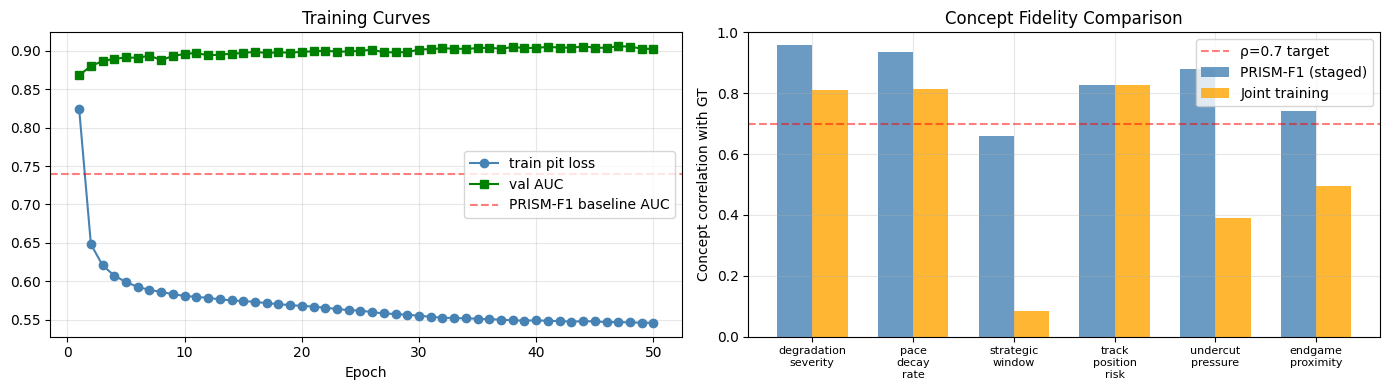


EXPERIMENT SUMMARY

  PRISM-F1 (staged):    val AUC = 0.7402
  Joint (this run):     val AUC = 0.9060
  Delta:                +0.1658

  PRISM-F1 concept ρ range: [0.661, 0.960]
  Joint concept ρ range:    [0.086, 0.826]

  Joint model parameters:   717
  PRISM-F1 runtime params:  3,357


In [14]:
# ── Save checkpoint
ckpt_path = CHECKPOINTS_DIR / 'joint_model_experiment.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'best_epoch': best_epoch,
    'best_val_auc': best_val_auc,
    'history': history,
    'lambda_concept': LAMBDA_CONCEPT,
}, ckpt_path)
print(f"\nCheckpoint saved to: {ckpt_path}")


# ── Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: training curves
axes[0].plot(history['epoch'], history['train_loss_pit'], 'o-', label='train pit loss', color='steelblue')
axes[0].plot(history['epoch'], history['val_auc'], 's-', label='val AUC', color='green')
axes[0].axhline(0.7402, color='red', linestyle='--', alpha=0.5, label='PRISM-F1 baseline AUC')
axes[0].set_xlabel('Epoch')
axes[0].set_title('Training Curves')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: concept correlation comparison
labels = [n.replace('_', '\n') for n in CONCEPT_NAMES]
joint_corrs = [np.corrcoef(c_pred[:, j], c_true[:, j])[0, 1] for j in range(6)]
baseline_corrs = [prism_correlations[n] for n in CONCEPT_NAMES]
x_pos = np.arange(6)
width = 0.35
axes[1].bar(x_pos - width/2, baseline_corrs, width, label='PRISM-F1 (staged)', color='steelblue', alpha=0.8)
axes[1].bar(x_pos + width/2, joint_corrs, width, label='Joint training', color='orange', alpha=0.8)
axes[1].axhline(0.7, color='red', linestyle='--', alpha=0.5, label='ρ=0.7 target')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_ylabel('Concept correlation with GT')
axes[1].set_title('Concept Fidelity Comparison')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()


# ── Final summary
print("\n" + "=" * 70)
print("EXPERIMENT SUMMARY")
print("=" * 70)
print(f"\n  PRISM-F1 (staged):    val AUC = 0.7402")
print(f"  Joint (this run):     val AUC = {best_val_auc:.4f}")
print(f"  Delta:                {(best_val_auc - 0.7402):+.4f}")
print(f"\n  PRISM-F1 concept ρ range: [0.661, 0.960]")
print(f"  Joint concept ρ range:    [{min(joint_corrs):.3f}, {max(joint_corrs):.3f}]")
print(f"\n  Joint model parameters:   {n_params:,}")
print(f"  PRISM-F1 runtime params:  3,357")

LAMBDA ABLATION: 6 training runs

     λ |  val AUC |   mean ρ | corrs (per concept)                                          | best epoch |   time
----------------------------------------------------------------------------------------------------------------------------------
   0.0 |   0.9041 |   0.1739 | 0.32 0.40 -0.30 0.05 0.29 0.29                               |         28 | 945.7s
   0.1 |   0.9052 |   0.2525 | 0.06 0.55 0.02 0.38 0.39 0.12                                |         38 | 1167.2s
   0.5 |   0.9050 |   0.5404 | 0.83 0.84 0.05 0.77 0.40 0.34                                |         33 | 975.0s
   2.0 |   0.8979 |   0.7331 | 0.71 0.60 0.86 0.97 0.81 0.44                                |         28 | 829.2s
   5.0 |   0.9027 |   0.7591 | 0.85 0.44 0.91 1.00 0.97 0.39                                |         34 | 627.9s
  20.0 |   0.8891 |   0.8928 | 0.94 0.94 0.91 1.00 1.00 0.57                                |         35 | 389.8s

  PRISM-F1 baseline (staged):
    v

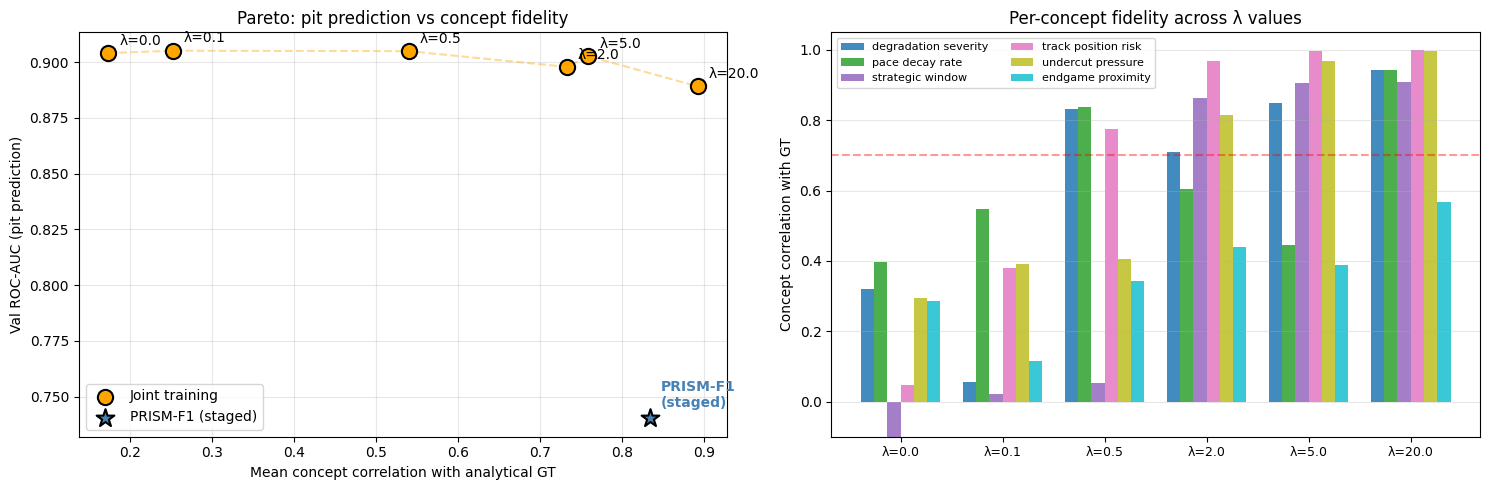


RESULTS TABLE

  Joint training results (in order of increasing λ):
       λ |  val AUC |   mean ρ | concepts below ρ=0.7     
  ----------------------------------------------------------------------
     0.0 |   0.9041 |   0.1739 | 6/6 concepts below 0.7
     0.1 |   0.9052 |   0.2525 | 6/6 concepts below 0.7
     0.5 |   0.9050 |   0.5404 | 3/6 concepts below 0.7
     2.0 |   0.8979 |   0.7331 | 2/6 concepts below 0.7
     5.0 |   0.9027 |   0.7591 | 2/6 concepts below 0.7
    20.0 |   0.8891 |   0.8928 | 1/6 concepts below 0.7

  PRISM-F1 (staged):
  staged |   0.7402 |   0.8343 | 1/6 concepts below 0.7

Results saved to: D:\PIT_Stop_predicton\cookbook_prism_f1\outputs\lambda_ablation_results.csv


In [15]:
# Notebook 06b — Lambda Ablation: AUC vs Concept Fidelity Pareto Curve

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import roc_auc_score

# Reproducibility
SEED = 42

# (Assumes previous notebook state is still in memory: x_arr, c_gt_arr, pit_arr,
#  train_mask, val_mask, FEATURE_NAMES, CONCEPT_NAMES, DEVICE, etc.
#  If you ran this in a new session, re-run sections 1-2 of Notebook 06 first.)


# ── Re-define the joint model classes for self-containedness
class JointConceptBlock(nn.Module):
    def __init__(self, input_dim=13, concept_dim=6, hidden_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, concept_dim)
    def forward(self, x):
        h = F.relu(self.ln1(self.fc1(x)))
        return torch.sigmoid(self.fc2(h))


class JointDecisionBlock(nn.Module):
    def __init__(self, concept_dim=6):
        super().__init__()
        self.linear = nn.Linear(concept_dim, 1)
    def forward(self, c):
        return self.linear(c).squeeze(-1)


class JointModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.concept_block = JointConceptBlock()
        self.decision_block = JointDecisionBlock()
    def forward(self, x):
        c = self.concept_block(x)
        logit = self.decision_block(c)
        return logit, c


def train_one_lambda(lambda_concept, epochs=50, patience=8, verbose=False):
    """Train a joint model with a specific λ_concept; return all the metrics."""
    torch.manual_seed(SEED)
    model = JointModel().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
    
    pos_weight_t = torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
    
    best_val_auc = 0.0
    best_epoch = 0
    best_state = None
    epochs_since_improvement = 0
    
    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        for xb, cb, pb in train_loader:
            xb = xb.to(DEVICE); cb = cb.to(DEVICE); pb = pb.to(DEVICE)
            optimizer.zero_grad()
            logit, c_pred = model(xb)
            loss_pit = F.binary_cross_entropy_with_logits(logit, pb, pos_weight=pos_weight_t)
            loss_concept = F.mse_loss(c_pred, cb)
            loss = loss_pit + lambda_concept * loss_concept
            loss.backward()
            optimizer.step()
        
        # Val
        model.eval()
        all_probs, all_targets = [], []
        with torch.no_grad():
            for xb, cb, pb in val_loader:
                xb = xb.to(DEVICE); pb = pb.to(DEVICE)
                logit, _ = model(xb)
                all_probs.append(torch.sigmoid(logit).cpu().numpy())
                all_targets.append(pb.cpu().numpy())
        val_auc = roc_auc_score(np.concatenate(all_targets), np.concatenate(all_probs))
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1
            if epochs_since_improvement >= patience:
                break
    
    # Restore best and compute concept correlations + decision weights
    model.load_state_dict(best_state)
    model.eval()
    all_c_pred, all_c_true = [], []
    with torch.no_grad():
        for xb, cb, pb in val_loader:
            xb = xb.to(DEVICE)
            _, c_pred = model(xb)
            all_c_pred.append(c_pred.cpu().numpy())
            all_c_true.append(cb.numpy())
    c_pred = np.concatenate(all_c_pred)
    c_true = np.concatenate(all_c_true)
    
    concept_corrs = []
    for j in range(6):
        if c_true[:, j].std() < 1e-6 or c_pred[:, j].std() < 1e-6:
            concept_corrs.append(np.nan)
        else:
            concept_corrs.append(np.corrcoef(c_pred[:, j], c_true[:, j])[0, 1])
    
    weights = model.decision_block.linear.weight[0].detach().cpu().numpy()
    bias = model.decision_block.linear.bias.item()
    
    return {
        'lambda': lambda_concept,
        'val_auc': best_val_auc,
        'best_epoch': best_epoch,
        'concept_corrs': concept_corrs,
        'mean_concept_corr': np.nanmean(concept_corrs),
        'decision_weights': weights,
        'decision_bias': bias,
    }


# ── Run the sweep
print("=" * 70)
print("LAMBDA ABLATION: 6 training runs")
print("=" * 70)

LAMBDAS = [0.0, 0.1, 0.5, 2.0, 5.0, 20.0]
results = []

print(f"\n{'λ':>6s} | {'val AUC':>8s} | {'mean ρ':>8s} | "
      f"{'corrs (per concept)':<60s} | {'best epoch':>10s} | {'time':>6s}")
print("-" * 130)

for lam in LAMBDAS:
    t0 = time.time()
    print(f"  Training λ={lam}...", end='\r')
    r = train_one_lambda(lam, epochs=50, patience=8)
    elapsed = time.time() - t0
    results.append(r)
    
    corrs_str = " ".join(f"{c:.2f}" for c in r['concept_corrs'])
    print(f"{lam:>6.1f} | {r['val_auc']:>8.4f} | {r['mean_concept_corr']:>8.4f} | "
          f"{corrs_str:<60s} | {r['best_epoch']:>10d} | {elapsed:>5.1f}s")


# ── PRISM-F1 baseline as reference
prism_baseline = {
    'lambda': 'staged',
    'val_auc': 0.7402,
    'mean_concept_corr': np.mean([0.960, 0.935, 0.661, 0.828, 0.879, 0.743]),
    'concept_corrs': [0.960, 0.935, 0.661, 0.828, 0.879, 0.743],
    'decision_weights': np.array([+1.0731, -0.1885, +1.1990, -0.2383, +1.6079, -2.9945]),
    'decision_bias': -0.6079,
}
print(f"\n  PRISM-F1 baseline (staged):")
print(f"    val AUC: {prism_baseline['val_auc']:.4f}")
print(f"    mean concept correlation: {prism_baseline['mean_concept_corr']:.4f}")


# ── Plot: the Pareto curve
print("\n" + "=" * 70)
print("PARETO CURVE: AUC vs Concept Fidelity")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: the main Pareto plot
ax1 = axes[0]
xs = [r['mean_concept_corr'] for r in results]
ys = [r['val_auc'] for r in results]
lambdas = [r['lambda'] for r in results]

# Joint training points
ax1.scatter(xs, ys, s=120, c='orange', edgecolors='black', linewidth=1.5,
            label='Joint training', zorder=3)
for x, y, lam in zip(xs, ys, lambdas):
    ax1.annotate(f"λ={lam}", (x, y), textcoords="offset points", xytext=(8, 6), fontsize=10)

# Connect them with a line
sorted_idx = np.argsort(xs)
ax1.plot(np.array(xs)[sorted_idx], np.array(ys)[sorted_idx], '--', alpha=0.4, color='orange')

# PRISM-F1 baseline
ax1.scatter([prism_baseline['mean_concept_corr']], [prism_baseline['val_auc']],
            s=180, c='steelblue', edgecolors='black', linewidth=1.5, marker='*',
            label='PRISM-F1 (staged)', zorder=3)
ax1.annotate("PRISM-F1\n(staged)",
             (prism_baseline['mean_concept_corr'], prism_baseline['val_auc']),
             textcoords="offset points", xytext=(8, 8), fontsize=10,
             fontweight='bold', color='steelblue')

ax1.set_xlabel('Mean concept correlation with analytical GT')
ax1.set_ylabel('Val ROC-AUC (pit prediction)')
ax1.set_title('Pareto: pit prediction vs concept fidelity')
ax1.grid(alpha=0.3)
ax1.legend(loc='lower left')

# Right: per-concept correlations across lambdas
ax2 = axes[1]
lambda_labels = [f"λ={r['lambda']}" for r in results]
x_positions = np.arange(len(LAMBDAS))
width = 0.13

baseline_corrs = [0.960, 0.935, 0.661, 0.828, 0.879, 0.743]
colors = plt.cm.tab10(np.linspace(0, 1, 6))

for j, name in enumerate(CONCEPT_NAMES):
    concept_corrs_across_lambdas = [r['concept_corrs'][j] for r in results]
    ax2.bar(x_positions + j*width - 2.5*width, concept_corrs_across_lambdas, width,
            label=name.replace('_', ' '), color=colors[j], alpha=0.85)

ax2.set_xticks(x_positions)
ax2.set_xticklabels(lambda_labels, fontsize=9)
ax2.set_ylabel('Concept correlation with GT')
ax2.set_title('Per-concept fidelity across λ values')
ax2.legend(fontsize=8, loc='upper left', ncol=2)
ax2.grid(alpha=0.3, axis='y')
ax2.axhline(0.7, color='red', linestyle='--', alpha=0.4, label='ρ=0.7 target')
ax2.set_ylim(-0.1, 1.05)

plt.tight_layout()
plt.show()


# ── Summary table
print("\n" + "=" * 70)
print("RESULTS TABLE")
print("=" * 70)

print(f"\n  Joint training results (in order of increasing λ):")
print(f"  {'λ':>6s} | {'val AUC':>8s} | {'mean ρ':>8s} | {'concepts below ρ=0.7':<25s}")
print(f"  {'-'*70}")
for r in results:
    below_threshold = sum(1 for c in r['concept_corrs'] if c < 0.7)
    print(f"  {r['lambda']:>6.1f} | {r['val_auc']:>8.4f} | {r['mean_concept_corr']:>8.4f} | "
          f"{below_threshold}/6 concepts below 0.7")
print(f"\n  PRISM-F1 (staged):")
below_threshold = sum(1 for c in prism_baseline['concept_corrs'] if c < 0.7)
print(f"  {'staged':>6s} | {prism_baseline['val_auc']:>8.4f} | "
      f"{prism_baseline['mean_concept_corr']:>8.4f} | "
      f"{below_threshold}/6 concepts below 0.7")


# ── Save results for the write-up
ablation_path = OUTPUTS_DIR / 'lambda_ablation_results.csv'
ablation_df = pd.DataFrame([
    {
        'lambda': str(r['lambda']),
        'val_auc': r['val_auc'],
        'mean_concept_corr': r['mean_concept_corr'],
        **{f'corr_{CONCEPT_NAMES[j]}': r['concept_corrs'][j] for j in range(6)},
        **{f'weight_{CONCEPT_NAMES[j]}': r['decision_weights'][j] for j in range(6)},
        'bias': r['decision_bias'],
        'best_epoch': r['best_epoch'],
    }
    for r in results
])
# Add PRISM-F1 baseline as last row
ablation_df.loc[len(ablation_df)] = {
    'lambda': 'staged',
    'val_auc': prism_baseline['val_auc'],
    'mean_concept_corr': prism_baseline['mean_concept_corr'],
    **{f'corr_{CONCEPT_NAMES[j]}': prism_baseline['concept_corrs'][j] for j in range(6)},
    **{f'weight_{CONCEPT_NAMES[j]}': prism_baseline['decision_weights'][j] for j in range(6)},
    'bias': prism_baseline['decision_bias'],
    'best_epoch': 7,
}
ablation_df.to_csv(ablation_path, index=False)
print(f"\nResults saved to: {ablation_path}")

In [17]:
# Retrain λ=20 and save checkpoint for submission

torch.manual_seed(SEED)
model_lam20 = JointModel().to(DEVICE)
optimizer = torch.optim.AdamW(model_lam20.parameters(), lr=1e-3, weight_decay=1e-5)
pos_weight_t = torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)

LAMBDA_CONCEPT = 20.0
EPOCHS = 50
PATIENCE = 8
best_val_auc = 0.0
best_epoch = 0
best_state = None
epochs_since_improvement = 0

print(f"Training joint model with λ={LAMBDA_CONCEPT}...")
print(f"{'epoch':>5s} | {'val_auc':>8s} | note")
print("-" * 40)

for epoch in range(1, EPOCHS + 1):
    model_lam20.train()
    for xb, cb, pb in train_loader:
        xb = xb.to(DEVICE); cb = cb.to(DEVICE); pb = pb.to(DEVICE)
        optimizer.zero_grad()
        logit, c_pred = model_lam20(xb)
        loss_pit = F.binary_cross_entropy_with_logits(logit, pb, pos_weight=pos_weight_t)
        loss_concept = F.mse_loss(c_pred, cb)
        loss = loss_pit + LAMBDA_CONCEPT * loss_concept
        loss.backward()
        optimizer.step()
    
    model_lam20.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for xb, cb, pb in val_loader:
            xb = xb.to(DEVICE)
            logit, _ = model_lam20(xb)
            all_probs.append(torch.sigmoid(logit).cpu().numpy())
            all_targets.append(pb.cpu().numpy())
    val_auc = roc_auc_score(np.concatenate(all_targets), np.concatenate(all_probs))
    
    note = ""
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch
        best_state = {k: v.cpu().clone() for k, v in model_lam20.state_dict().items()}
        epochs_since_improvement = 0
        note = "↑ new best"
    else:
        epochs_since_improvement += 1
        if epochs_since_improvement >= PATIENCE:
            note = "early stop"
    
    print(f"{epoch:>5d} | {val_auc:>8.4f} | {note}")
    if epochs_since_improvement >= PATIENCE:
        break

model_lam20.load_state_dict(best_state)
print(f"\nBest val AUC = {best_val_auc:.4f} at epoch {best_epoch}")

# Save with a distinct name
ckpt_path = CHECKPOINTS_DIR / 'joint_model_lambda20.pt'
torch.save({
    'model_state_dict': model_lam20.state_dict(),
    'best_epoch': best_epoch,
    'best_val_auc': best_val_auc,
    'lambda_concept': 20.0,
}, ckpt_path)
print(f"Saved to: {ckpt_path}")

Training joint model with λ=20.0...
epoch |  val_auc | note
----------------------------------------
    1 |   0.7488 | ↑ new best
    2 |   0.7802 | ↑ new best
    3 |   0.7994 | ↑ new best
    4 |   0.8253 | ↑ new best
    5 |   0.8295 | ↑ new best
    6 |   0.8401 | ↑ new best
    7 |   0.8466 | ↑ new best
    8 |   0.8618 | ↑ new best
    9 |   0.8696 | ↑ new best
   10 |   0.8714 | ↑ new best
   11 |   0.8706 | 
   12 |   0.8726 | ↑ new best
   13 |   0.8767 | ↑ new best
   14 |   0.8782 | ↑ new best
   15 |   0.8782 | 
   16 |   0.8806 | ↑ new best
   17 |   0.8759 | 
   18 |   0.8807 | ↑ new best
   19 |   0.8769 | 
   20 |   0.8822 | ↑ new best
   21 |   0.8790 | 
   22 |   0.8826 | ↑ new best
   23 |   0.8779 | 
   24 |   0.8827 | ↑ new best
   25 |   0.8851 | ↑ new best
   26 |   0.8816 | 
   27 |   0.8848 | 
   28 |   0.8855 | ↑ new best
   29 |   0.8863 | ↑ new best
   30 |   0.8839 | 
   31 |   0.8841 | 
   32 |   0.8855 | 
   33 |   0.8881 | ↑ new best
   34 |   0.8879 | 

In [19]:
# Joint Model Inference on Kaggle Test Set + Submission

from pathlib import Path
import numpy as np
import pandas as pd
import time

import torch
import torch.nn as nn
import torch.nn.functional as F

# Paths
PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
CHECKPOINTS_DIR = PROJECT_ROOT / 'checkpoints'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)

X_TEST_PICKLE = DATA_DIR / 'x_test.pkl'
JOINT_CHECKPOINT = CHECKPOINTS_DIR / 'joint_model_lambda20.pt'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

INPUT_DIM = 13
CONCEPT_DIM = 6

FEATURE_NAMES = [
    'lap_time_norm', 'lap_time_delta', 'cumulative_degradation',
    'tyre_life_norm', 'compound_soft', 'compound_medium', 'compound_hard',
    'compound_inter', 'compound_wet', 'position_norm', 'position_change_norm',
    'race_progress', 'stint_norm',
]


# ── Re-define joint model classes (must match training exactly)
class JointConceptBlock(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, concept_dim=CONCEPT_DIM, hidden_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, concept_dim)
    def forward(self, x):
        h = F.relu(self.ln1(self.fc1(x)))
        return torch.sigmoid(self.fc2(h))


class JointDecisionBlock(nn.Module):
    def __init__(self, concept_dim=CONCEPT_DIM):
        super().__init__()
        self.linear = nn.Linear(concept_dim, 1)
    def forward(self, c):
        return self.linear(c).squeeze(-1)


class JointModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.concept_block = JointConceptBlock()
        self.decision_block = JointDecisionBlock()
    def forward(self, x):
        c = self.concept_block(x)
        logit = self.decision_block(c)
        return logit, c


# ── Load checkpoint
print("=" * 70)
print("LOADING JOINT MODEL CHECKPOINT")
print("=" * 70)

ckpt = torch.load(JOINT_CHECKPOINT, weights_only=False)
model = JointModel().to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"\n  Best epoch:       {ckpt['best_epoch']}")
print(f"  Best val AUC:     {ckpt['best_val_auc']:.4f}")
print(f"  Lambda used:      {ckpt['lambda_concept']}")
print(f"  Total parameters: {n_params:,}")


# ── Load test data
print("\n" + "=" * 70)
print("LOADING KAGGLE TEST SET")
print("=" * 70)

x_test_df = pd.read_pickle(X_TEST_PICKLE)
x_cols = [f'x_{n}' for n in FEATURE_NAMES]
x_test_arr = x_test_df[x_cols].values.astype(np.float32)
test_ids = x_test_df['id'].values

print(f"\n  Test rows:    {len(x_test_arr):,}")
print(f"  Feature dim:  {x_test_arr.shape[1]}")
print(f"  id range:     [{test_ids.min()}, {test_ids.max()}]")


# ── Run inference (chunked)
print("\n" + "=" * 70)
print("RUNNING INFERENCE")
print("=" * 70)

t_start = time.time()
chunk_size = 50000
all_probs = []

with torch.no_grad():
    x_tensor = torch.from_numpy(x_test_arr).to(DEVICE)
    for i in range(0, len(x_tensor), chunk_size):
        chunk = x_tensor[i:i+chunk_size]
        logit, _ = model(chunk)
        probs = torch.sigmoid(logit).cpu().numpy()
        all_probs.append(probs)
        print(f"  Processed {min(i+chunk_size, len(x_tensor)):,} / {len(x_tensor):,}")

test_probs = np.concatenate(all_probs, axis=0)
print(f"\n  Inference complete in {time.time() - t_start:.1f}s")


# ── Sanity checks
print("\n" + "=" * 70)
print("INFERENCE SANITY CHECKS")
print("=" * 70)

print(f"\n  test_probs shape:   {test_probs.shape}")
print(f"  Any NaN?            {np.isnan(test_probs).any()}")
print(f"  Any Inf?            {np.isinf(test_probs).any()}")
print(f"  Probability range:  [{test_probs.min():.4f}, {test_probs.max():.4f}]")
print(f"  Mean probability:   {test_probs.mean():.4f}")
print(f"  Frac > 0.5:         {(test_probs > 0.5).mean() * 100:.2f}%")


# ── Build submission
print("\n" + "=" * 70)
print("BUILDING SUBMISSION CSV")
print("=" * 70)

submission = pd.DataFrame({
    'id': test_ids,
    'PitNextLap': test_probs.astype(np.float32),
})
submission = submission.sort_values('id').reset_index(drop=True)

print(f"\n  Submission shape:  {submission.shape}")
print(f"  Columns:           {list(submission.columns)}")
print(f"  First 5 rows:")
print(submission.head().to_string(index=False))

# Final sanity
assert not submission['PitNextLap'].isna().any(), "NaN in submission"
assert (submission['PitNextLap'] >= 0).all() and (submission['PitNextLap'] <= 1).all(), "out of range"
assert submission['id'].nunique() == len(submission), "duplicate ids"
print(f"\n  All sanity checks passed.")


# ── Save with a distinctive name so it doesn't overwrite the PRISM-F1 submission
submission_path = OUTPUTS_DIR / 'submission_joint_model_1.csv'
submission.to_csv(submission_path, index=False)
print(f"\n  Submission saved to: {submission_path}")
print(f"  File size: {submission_path.stat().st_size / 1024:.1f} KB")

print(f"\n  Reference: PRISM-F1 (staged) leaderboard score was 0.70")
print(f"  Expected leaderboard for joint model: somewhere around val AUC 0.91 ± 0.03")
print(f"  Submit and report back the public score.")

LOADING JOINT MODEL CHECKPOINT

  Best epoch:       47
  Best val AUC:     0.8918
  Lambda used:      20.0
  Total parameters: 717

LOADING KAGGLE TEST SET

  Test rows:    188,165
  Feature dim:  13
  id range:     [439140, 627304]

RUNNING INFERENCE
  Processed 50,000 / 188,165
  Processed 100,000 / 188,165
  Processed 150,000 / 188,165
  Processed 188,165 / 188,165

  Inference complete in 0.1s

INFERENCE SANITY CHECKS

  test_probs shape:   (188165,)
  Any NaN?            False
  Any Inf?            False
  Probability range:  [0.0000, 0.9958]
  Mean probability:   0.3613
  Frac > 0.5:         32.80%

BUILDING SUBMISSION CSV

  Submission shape:  (188165, 2)
  Columns:           ['id', 'PitNextLap']
  First 5 rows:
    id  PitNextLap
439140    0.025495
439141    0.063942
439142    0.069682
439143    0.313548
439144    0.931334

  All sanity checks passed.

  Submission saved to: D:\PIT_Stop_predicton\cookbook_prism_f1\outputs\submission_joint_model_1.csv
  File size: 3479.8 KB

  R